C:\Users\Lenovo\AppData\Local\Temp\ipykernel_205256\2132807323.py:183: DtypeWarning: Columns (16) have mixed types. Specify dtype option on import or set low_memory=False.
  dfb_ab = pd.read_csv(r"D:\NC\Data\rivernet\newdata8\Abundance.csv")


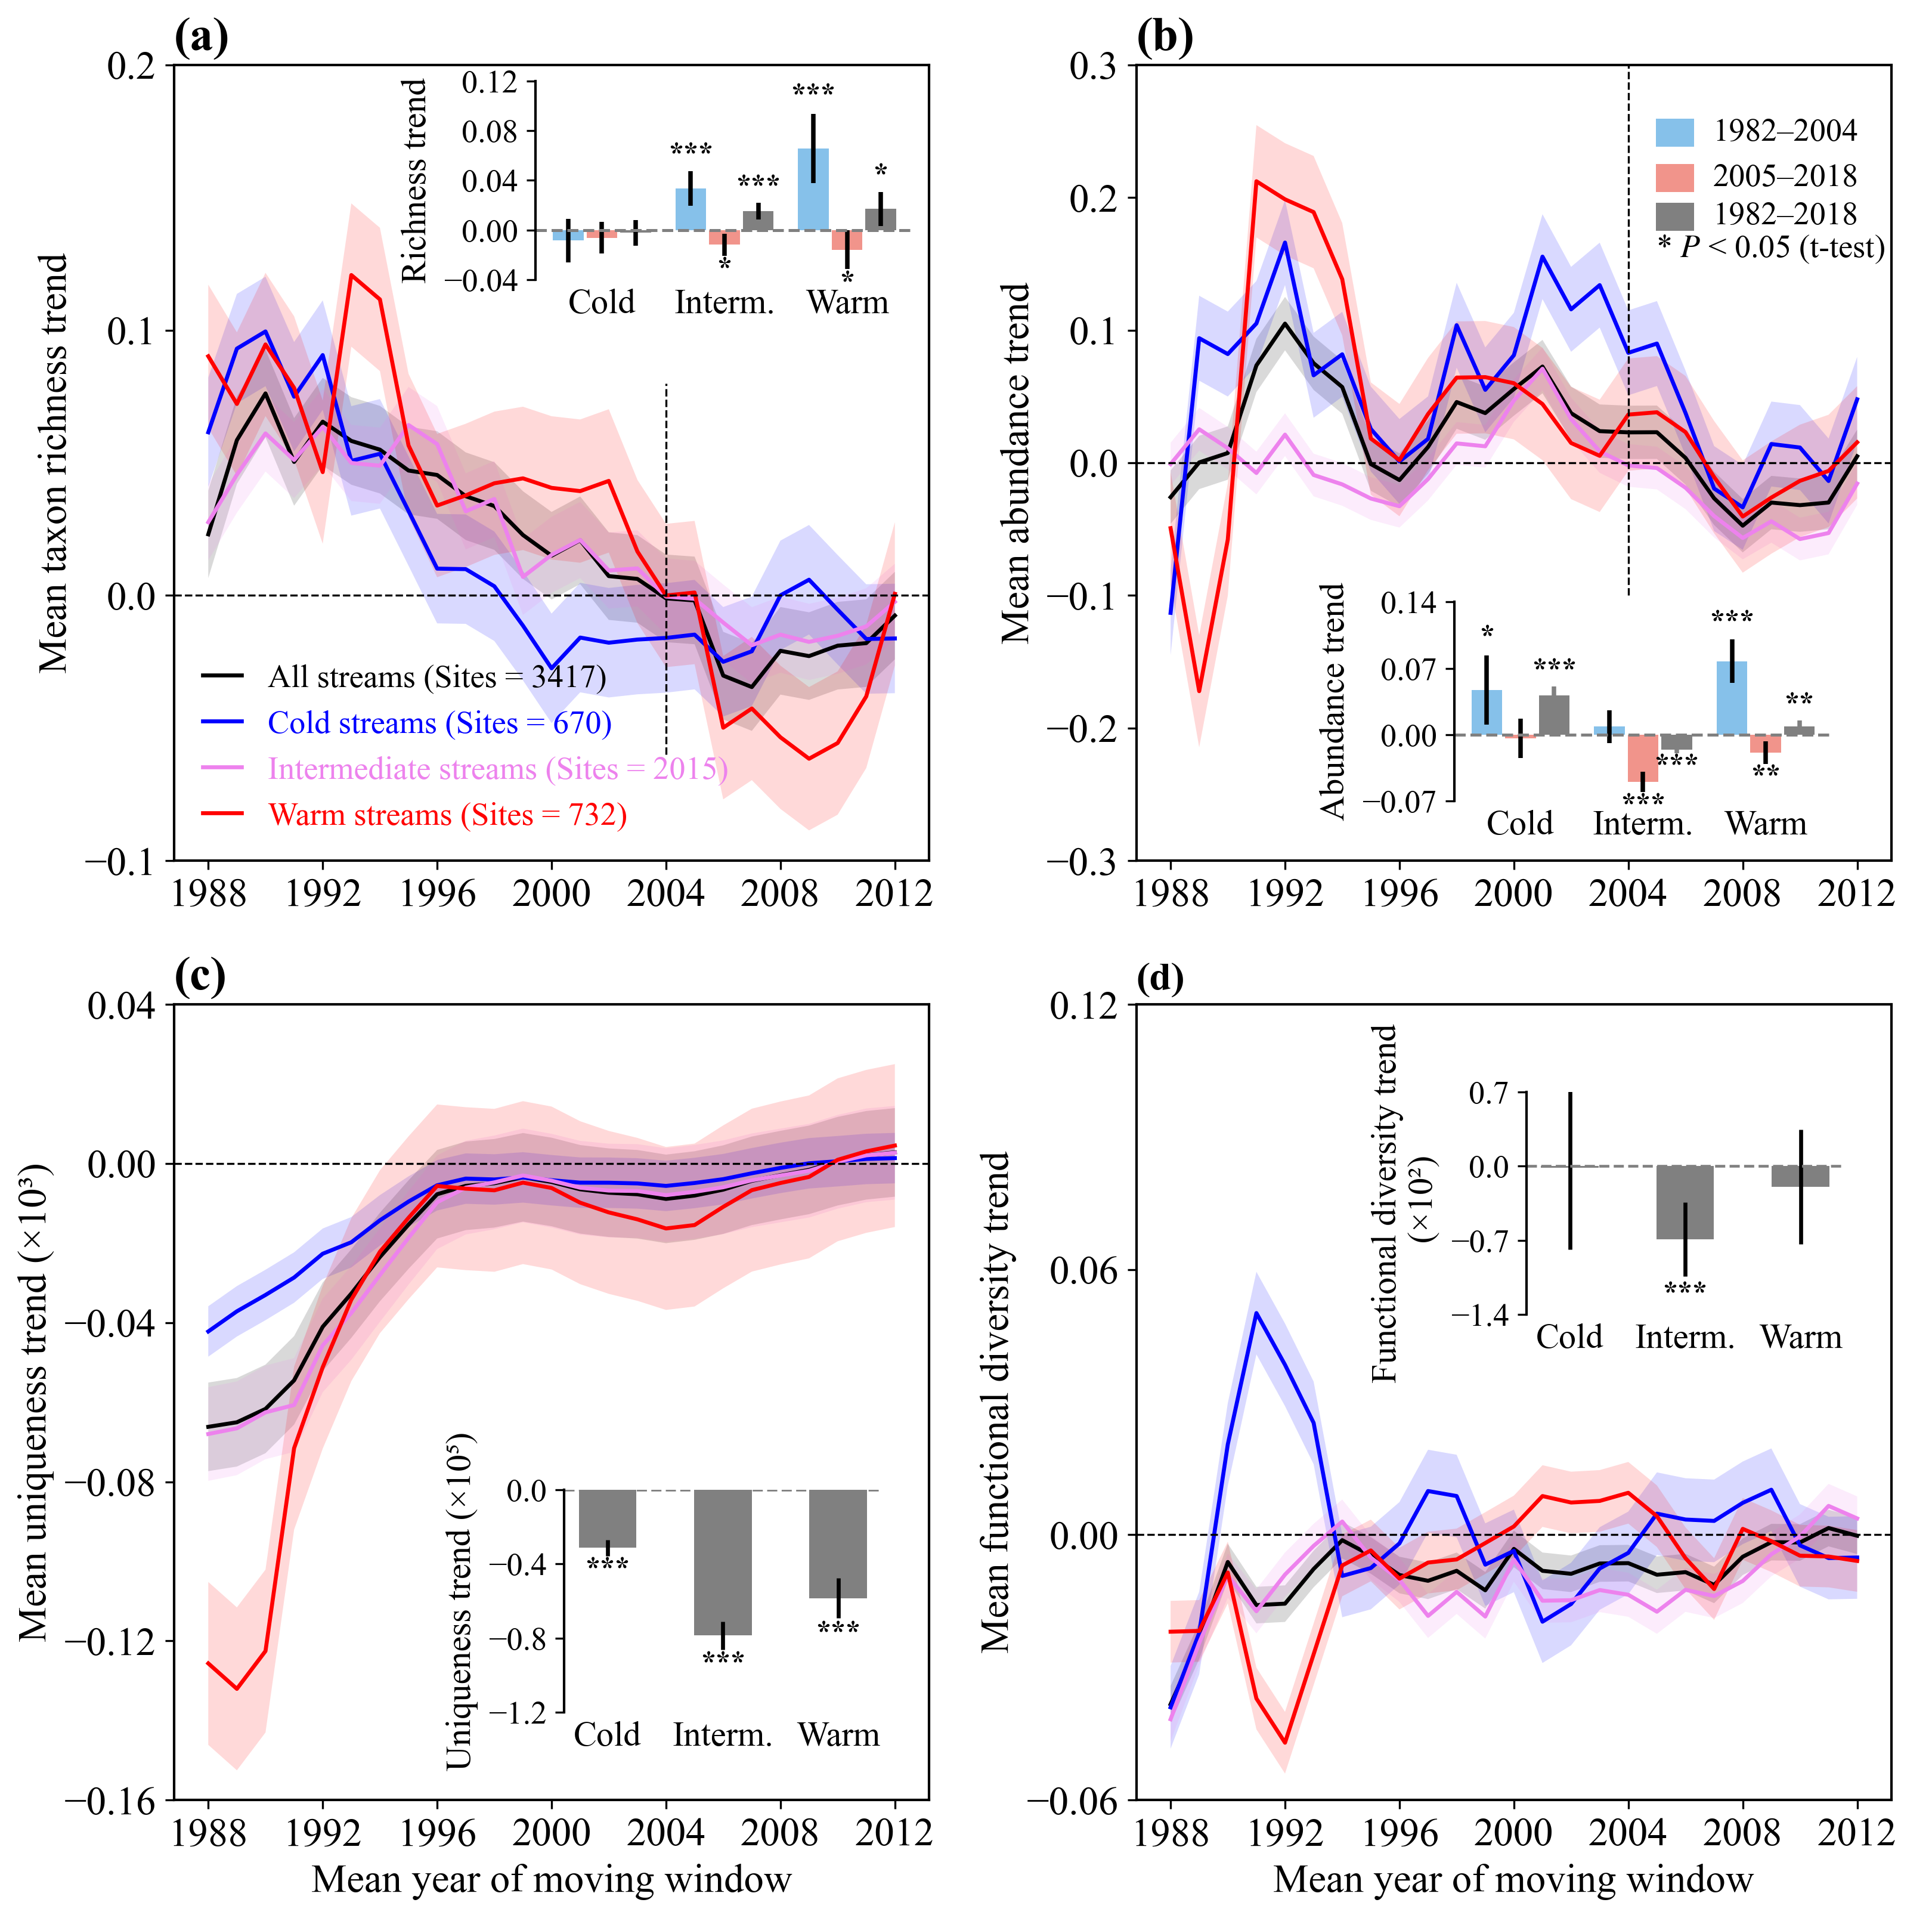

In [ ]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import theilslopes, ttest_1samp
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

def calc_window_trend(
    df_zone,
    value_col,
    group_cols=["SiteID"],
    start_year=1982,
    end_year=2018,
    window=10,
    min_years=3,
    min_sites=5,
    trim_q=(5, 95)
):
    """
    General moving-window Theil–Sen trend
    """
    results = []
    half = window // 2

    for center in range(start_year + half, end_year - half + 1):

        df_win = df_zone[
            (df_zone["year"] >= center - half) &
            (df_zone["year"] <= center + half)
        ]

        slopes = []

        for _, sub in df_win.groupby(group_cols):

            vals  = sub[value_col].values
            years = sub["year"].values
            ok = np.isfinite(vals)

            if ok.sum() < min_years:
                continue

            try:
                slope, _, _, _ = theilslopes(vals[ok], years[ok])
                if np.isfinite(slope):
                    slopes.append(slope)
            except Exception:
                continue

        if len(slopes) < min_sites:
            continue

        arr = np.asarray(slopes)
        ql, qh = np.percentile(arr, trim_q)
        arr = arr[(arr >= ql) & (arr <= qh)]

        if len(arr) < min_sites:
            continue

        results.append({
            "center_year": center,
            "mean_slope": np.mean(arr),
            "n_group": len(slopes),
            "n_group_trim": len(arr)
        })

    return pd.DataFrame(results)

def drop_edge_years(df, n=1):
    if df is None or df.empty:
        return df
    if len(df) <= 2 * n:
        return df.iloc[0:0]
    return df.iloc[n:-n].reset_index(drop=True)


plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 16,
    "mathtext.fontset": "stix",
    "axes.linewidth": 1,
    "axes.edgecolor": "black",
    "axes.grid": False,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.color": "black",
    "ytick.color": "black",
})

colors = {
    "All": "black",
    "Cold": "#0000ff",
    "Intermediate": "#ed82ed",
    "Warm": "#ff0000",
    "All streams": "black",
    "Cold streams": "#0000ff",
    "Intermediate streams": "#ed82ed",
    "Warm streams": "#ff0000"
}

zones_all = ["All", "Cold", "Intermediate", "Warm"]
zone_labels = ["Cold", "Intermediate", "Warm", "All"]
fig, axes = plt.subplots(2, 2, figsize=(11, 11), dpi=300)

# =========================================================
# (a) Mean site richness trend 
# =========================================================
ax = axes[0, 0]

dfb = pd.read_csv(r"D:\NC\Data\rivernet\inputdata\Richness.csv")
dfb = dfb.dropna(subset=["year", "species_richness", "SiteID", "zone"])
zones_map = {
    "Cold streams": "Cold",
    "Intermediate streams": "Intermediate",
    "Warm streams": "Warm"
}

results_dict = {
    "All streams": calc_window_trend(dfb, "species_richness")
}
for lab, z in zones_map.items():
    results_dict[lab] = calc_window_trend(
        dfb[dfb.zone.str.contains(z, case=False, na=False)],
        "species_richness"
    )

site_count_dict = {"All streams": dfb.SiteID.nunique()}
for lab, z in zones_map.items():
    site_count_dict[lab] = dfb[dfb.zone.str.contains(z, case=False)].SiteID.nunique()

for zone in ["All streams", "Cold streams", "Intermediate streams", "Warm streams"]:
    res = results_dict[zone]
    res_plot = drop_edge_years(res, n=1)
    if res_plot.empty:
        continue
    ax.plot(
        res_plot.center_year, res_plot.mean_slope,
        color=colors[zone],
        lw=1.6,
        label=f"{zone} (Sites = {site_count_dict[zone]})"
    )

    ax.fill_between(
        res_plot.center_year,
        res_plot.mean_slope - res_plot.mean_slope.std() / 2,
        res_plot.mean_slope + res_plot.mean_slope.std() / 2,
        color=colors[zone],
        alpha=0.15,
        edgecolor="none"
    )

ax.axhline(0, color="k", ls="--", lw=0.8)
ax.vlines(
    x=2004,
    ymin=-0.06,
    ymax=0.08,
    color="k",
    linestyles="--",
    lw=0.8
)
ax.set_xlabel("")
ax.set_ylabel("Mean taxon richness trend")
ax.set_xticks(np.arange(1988, 2014, 4))
ax.set_ylim(-0.1, 0.2)
ax.set_yticks(np.arange(-0.1, 0.21, 0.1))
ax.set_title("(a)", loc="left", fontweight="bold")
leg = ax.legend(frameon=False, fontsize=13, loc="lower left",handlelength=1.2)
for text in leg.get_texts():
    label = text.get_text()
    for key, col in colors.items():
        if key in label:
            text.set_color(col)


# =========================================================
# (b) Abundance moving window 
# =========================================================
ax = axes[0, 1]

dfb_ab = pd.read_csv(r"D:\NC\Data\rivernet\inputdata\Abundance.csv")
dfb_ab = dfb_ab.dropna(subset=["year", "abundance_std", "SiteID", "Species", "zone"])
results_dict_ab = {
    "All streams": calc_window_trend(
        dfb_ab,
        value_col="abundance_std",
        group_cols=["SiteID", "Species"]
    )
}
for lab, z in zones_map.items():
    results_dict_ab[lab] = calc_window_trend(
        dfb_ab[dfb_ab.zone.str.contains(z, case=False, na=False)],
        value_col="abundance_std",
        group_cols=["SiteID", "Species"]
    )

for zone in ["All streams", "Cold streams", "Intermediate streams", "Warm streams"]:
    res = results_dict_ab[zone]
    res_plot = drop_edge_years(res, n=1)
    if res_plot.empty:
        continue

    ax.plot(
        res_plot.center_year, res_plot.mean_slope,
        color=colors[zone],
        lw=1.6,
        label=zone
    )

    ax.fill_between(
        res_plot.center_year,
        res_plot.mean_slope - res_plot.mean_slope.std() / 2,
        res_plot.mean_slope + res_plot.mean_slope.std() / 2,
        color=colors[zone],
        alpha=0.15,
        edgecolor="none"
    )

ax.axhline(0, color="k", ls="--", lw=0.8)
ax.vlines(
    x=2004,
    ymin=-0.1,
    ymax=0.3,
    color="k",
    linestyles="--",
    lw=0.8
)
ax.set_xlabel("")
ax.set_ylabel("Mean abundance trend")
ax.set_xticks(np.arange(1988, 2014, 4))
ax.set_ylim(-0.3, 0.3)
ax.set_yticks(np.arange(-0.3, 0.31, 0.1))
ax.set_title("(b)", loc="left", fontweight="bold")

# =========================================================
# (a1) inset
# =========================================================
ax = inset_axes(
    axes[0, 0],
    width="50%",
    height="25%",
    loc="upper right",
    borderpad=0.4
)

zones = ["Cold", "Intermediate", "Warm"]
periods = ["1982_2004", "2005_2018"]
period_colors = ["#86c1ea", "#f1948b"]

bar_width = 0.30
gap = 0.03

offset_left   = -(bar_width + gap)   
offset_center = 0.0                  
offset_right  = +(bar_width + gap)   

df = pd.read_csv(r"D:\NC\Data\rivernet\inputdata\Richness_segmented_2004.csv")
df_all = pd.read_csv(r"D:\NC\Data\rivernet\inputdata\Richness_slope.csv")

group_gap = 1.2   
x_base = np.arange(len(zones)) * group_gap

for per, color in zip(periods, period_colors):

    if per == "1982_2004":
        xpos = x_base + offset_left
    elif per == "2005_2018":
        xpos = x_base + offset_center

    means, ses, stars = [], [], []

    for z in zones:
        vals = df[(df.period == per) & (df.zone == z)].sen_richness.dropna()

        means.append(vals.mean())
        se = vals.std(ddof=1) / np.sqrt(len(vals))
        ses.append(se)

        if len(vals) >= 2:
            _, p = ttest_1samp(vals, 0)
            stars.append("***" if p < 0.001 else
                         "**" if p < 0.01 else
                         "*"  if p < 0.05 else "")
        else:
            stars.append("")

    ax.bar(
        xpos, means,
        width=bar_width,
        edgecolor='none',
        facecolor=color,
        lw=2
    )

    ax.errorbar(
        xpos, means,
        yerr=np.array(ses) * 1.96,
        fmt="none",
        ecolor='black',
        lw=1.8
    )

    for i, star in enumerate(stars):
        if star:
            ci = ses[i] * 1.96
            y = means[i] + ci * 1.1 if means[i] >= 0 else means[i] - ci * 1.1
            ax.text(
                xpos[i], y, star,
                ha="center",
                va="bottom" if means[i] >= 0 else "top",
                fontsize=12,
                fontweight="bold"
            )

xpos = x_base + offset_right
means, ses, stars = [], [], []

for z in zones:
    vals = df_all[df_all["zone"] == z]["slope_richness"].dropna()

    means.append(vals.mean())
    se = vals.std(ddof=1) / np.sqrt(len(vals))
    ses.append(se)

    if len(vals) >= 2:
        _, p = ttest_1samp(vals, 0)
        stars.append("***" if p < 0.001 else
                     "**" if p < 0.01 else
                     "*"  if p < 0.05 else "")
    else:
        stars.append("")

ax.bar(
    xpos, means,
    width=bar_width,
    edgecolor="none",
    facecolor="gray",
    lw=2
)

ax.errorbar(
    xpos, means,
    yerr=np.array(ses) * 1.96,
    fmt="none",
    ecolor="black",
    lw=1.8
)

for i, star in enumerate(stars):
    if star:
        ci = ses[i] * 1.96
        y = means[i] + ci * 1.1 if means[i] >= 0 else means[i] - ci * 1.1
        ax.text(
            xpos[i], y, star,
            ha="center",
            va="bottom" if means[i] >= 0 else "top",
            fontsize=12,
            fontweight="bold"
        )

ax.axhline(0, color="gray", lw=1.2, ls="--")
ax.set_xticks(x_base)
ax.set_xticklabels(["Cold", "Interm.", "Warm"], fontsize=14)
ax.set_ylabel("Richness trend", fontsize=14)
ax.set_ylim(-0.04, 0.12)
ax.set_yticks([-0.04, 0.00, 0.04, 0.08, 0.12])
ax.tick_params(axis="y", labelsize=13)
for spine in ["top", "right", "bottom"]:
    ax.spines[spine].set_visible(False)
ax.tick_params(axis="x", which="both", length=0)

ax_leg = inset_axes(
    axes[0, 1],
    width="36%",
    height="22%",
    loc="upper right",
    bbox_to_anchor=(0.03, -0.05, 1, 1),  
    bbox_transform=axes[0,1].transAxes,
    borderpad=0
)
y_shift = 0.08
box_w = 0.14
box_h = 0.16
lw = 2
ax_leg.add_patch(
    plt.Rectangle(
        (0.05, 0.68 + y_shift), box_w, box_h,
        facecolor='#86c1ea', edgecolor="none", linewidth=lw
    )
)
ax_leg.text(0.26, 0.76 + y_shift, "1982–2004",
            va="center", fontsize=13)
ax_leg.add_patch(
    plt.Rectangle(
        (0.05, 0.42 + y_shift), box_w, box_h,
        facecolor='#f1948b', edgecolor="none", linewidth=lw
    )
)
ax_leg.text(0.26, 0.50 + y_shift, "2005–2018",
            va="center", fontsize=13)
ax_leg.add_patch(
    plt.Rectangle(
        (0.05, 0.20 + y_shift), box_w, box_h,
        facecolor='gray', edgecolor="none", linewidth=lw
    )
)
ax_leg.text(0.26, 0.28 + y_shift, "1982–2018",
            va="center", fontsize=13)
ax_leg.text(
    0.05, 0.05 + y_shift,
    r"* $P$ < 0.05 (t-test)",
    fontsize=13
)

ax_leg.set_xlim(0, 1)
ax_leg.set_ylim(0, 1)
ax_leg.axis("off")

# =========================================================
# (b1) inset
# =========================================================
ax = inset_axes(
    axes[0, 1],
    width="50%",
    height="25%",
    loc="lower right",
    borderpad=1.5
)

zones = ["Cold", "Intermediate", "Warm"]
periods = ["1982_2004", "2005_2018"]
period_colors = ["#86c1ea", "#f1948b"]

bar_width = 0.30
gap = 0.03
offset_left   = -(bar_width + gap)  
offset_center = 0.0                  
offset_right  = +(bar_width + gap)   

df = pd.read_csv(r"D:\NC\Data\rivernet\inputdata\Abundance_segmented_2004.csv")
df_all = pd.read_csv(r"D:\NC\Data\rivernet\inputdata\Abundance_slope.csv")

group_gap = 1.2   
x_base = np.arange(len(zones)) * group_gap

for per, color in zip(periods, period_colors):

    if per == "1982_2004":
        xpos = x_base + offset_left
    elif per == "2005_2018":
        xpos = x_base + offset_center

    means, ses, stars = [], [], []
    for z in zones:
        vals = df[(df.period == per) & (df.zone == z)].sen_abundance_std.dropna()

        means.append(vals.mean())
        se = vals.std(ddof=1) / np.sqrt(len(vals))
        ses.append(se)

        if len(vals) >= 2:
            _, p = ttest_1samp(vals, 0)
            stars.append("***" if p < 0.001 else
                         "**" if p < 0.01 else
                         "*"  if p < 0.05 else "")
        else:
            stars.append("")

    ax.bar(
        xpos, means,
        width=bar_width,
        edgecolor='none',
        facecolor=color,
        lw=2
    )

    ax.errorbar(
        xpos, means,
        yerr=np.array(ses) * 1.96,
        fmt="none",
        ecolor='black',
        lw=1.8
    )

    for i, star in enumerate(stars):
        if star:
            ci = ses[i] * 1.96
            y = means[i] + ci * 1.1 if means[i] >= 0 else means[i] - ci * 1.1
            ax.text(
                xpos[i], y, star,
                ha="center",
                va="bottom" if means[i] >= 0 else "top",
                fontsize=12,
                fontweight="bold"
            )

xpos = x_base + offset_right
means, ses, stars = [], [], []

for z in zones:
    vals = df_all[df_all["zone"] == z]["slope_abundance"].dropna()

    means.append(vals.mean())
    se = vals.std(ddof=1) / np.sqrt(len(vals))
    ses.append(se)

    if len(vals) >= 2:
        _, p = ttest_1samp(vals, 0)
        stars.append("***" if p < 0.001 else
                     "**" if p < 0.01 else
                     "*"  if p < 0.05 else "")
    else:
        stars.append("")

ax.bar(
    xpos, means,
    width=bar_width,
    edgecolor="none",
    facecolor="gray",
    lw=2
)

ax.errorbar(
    xpos, means,
    yerr=np.array(ses) * 1.96,
    fmt="none",
    ecolor="gray",
    lw=1.8
)

for i, star in enumerate(stars):
    if star:
        ci = ses[i] * 1.96
        y = means[i] + ci * 1.1 if means[i] >= 0 else means[i] - ci * 1.1
        ax.text(
            xpos[i], y, star,
            ha="center",
            va="bottom" if means[i] >= 0 else "top",
            fontsize=12,
            fontweight="bold"
        )

ax.axhline(0, color="gray", lw=1.2, ls="--")
ax.set_xticks(x_base)
ax.set_xticklabels(["Cold", "Interm.", "Warm"], fontsize=14)
ax.set_ylabel("Abundance trend",fontsize=14)
ax.set_ylim(-0.07, 0.14)
ax.set_yticks([-0.07, 0.00, 0.07, 0.14])
ax.tick_params(axis="y", labelsize=13)

for spine in ["top", "right", "bottom"]:
    ax.spines[spine].set_visible(False)
ax.tick_params(axis="x", which="both", length=0)

# =========================================================
# (c) LCBD moving-window trend
# =========================================================
ax = axes[1, 0]

df_c = pd.read_csv(
    r"D:\NC\Data\rivernet\inputdata\Richness.csv"
)

df_c["SiteID"] = df_c["SiteID"].astype(str)
df_c["year"] = df_c["year"].astype(int)

zones_map_c = {
    "All streams": None,
    "Cold streams": "Cold",
    "Intermediate streams": "Intermediate",
    "Warm streams": "Warm",
}

results_c = {}
for label, key in zones_map_c.items():
    if key is None:
        results_c[label] = calc_window_trend(
            df_c,
            value_col="LCBD",
        )
    else:
        results_c[label] = calc_window_trend(
            df_c[df_c.zone.str.contains(key, case=False, na=False)],
            value_col="LCBD",
        )

scale = 1e3 

for zone in ["All streams", "Cold streams",
             "Intermediate streams", "Warm streams"]:

    res = results_c.get(zone)
    if res is None or res.empty:
        continue

    res_plot = drop_edge_years(res, n=1)
    if res_plot.empty:
        continue

    ax.plot(
        res_plot.center_year,
        res_plot.mean_slope * scale,
        color=colors[zone],
        lw=1.6,
    )

    ax.fill_between(
        res_plot.center_year,
        res_plot.mean_slope * scale - res_plot.mean_slope.std() / 2 * scale,
        res_plot.mean_slope * scale + res_plot.mean_slope.std() / 2 * scale,
        color=colors[zone],
        alpha=0.15,
        edgecolor="none"
    )
ax.axhline(0, color="k", ls="--", lw=0.8)
ax.set_xlabel("Mean year of moving window")
ax.set_ylabel("Mean uniqueness trend (×10³)")
ax.set_xticks(np.arange(1988, 2014, 4))
ax.set_ylim(-0.16, 0.04)
ax.set_yticks(np.arange(-0.16, 0.05, 0.04))
ax.set_title("(c)", loc="left", fontweight="bold")

# =========================================================
# (c1) inset
# =========================================================
ax_in = inset_axes(
    axes[1, 0],          
    width="42%",
    height="28%",
    loc="lower right",
    bbox_to_anchor=(0, 0.05, 1, 1),  
    bbox_transform=axes[1,0].transAxes,
    borderpad=1.2
)

df_bar = pd.read_csv(
    r"D:\NC\Data\rivernet\inputdata\Richness_slope.csv"
)
zones = ["Cold", "Intermediate", "Warm"]
x = np.arange(len(zones))

means, ses, stars = [], [], []
scale = 1e5 
for z in zones:
    vals = df_bar[df_bar["zone"] == z]["slope_LCBD"].dropna() * scale

    means.append(vals.mean())
    se = vals.std(ddof=1) / np.sqrt(len(vals))
    ses.append(se)

    if len(vals) >= 2:
        _, p = ttest_1samp(vals, 0)
        stars.append(
            "***" if p < 0.001 else
            "**"  if p < 0.01 else
            "*"   if p < 0.05 else ""
        )
    else:
        stars.append("")

ax_in.bar(
    x,
    means,
    width=0.5,
    edgecolor="none",
    facecolor="gray",
    lw=2
)
ax_in.errorbar(
    x,
    means,
    yerr=np.array(ses) * 1.96,
    fmt="none",
    ecolor="black",
    lw=1.6
)
for i, star in enumerate(stars):
    if star:
        ci = ses[i] * 1.96
        y = means[i] + ci * 1.15 if means[i] >= 0 else means[i] - ci * 1.15
        ax_in.text(
            x[i], y, star,
            ha="center",
            va="bottom" if means[i] >= 0 else "top",
            fontsize=12,
            fontweight="bold"
        )
ax_in.axhline(0, color="gray", lw=1.1, ls="--")
ax_in.set_xticks(x)
ax_in.set_xticklabels(["Cold", "Interm.", "Warm"], fontsize=14)
ax_in.set_ylabel("Uniqueness trend (×10⁵)", fontsize=14)
ax_in.set_ylim(-1.2, 0.0)
ax_in.set_yticks(np.arange(-1.2, 0.01, 0.4))
ax_in.tick_params(axis="y", labelsize=13)
for spine in ["top", "right", "bottom"]:
    ax_in.spines[spine].set_visible(False)
ax_in.tick_params(axis="x", length=0)

# =========================================================
# (d) SES_FDis moving-window trend
# =========================================================
ax = axes[1, 1]

df_fdis = pd.read_csv(
    r"D:\NC\Data\rivernet\inputdata\Richness.csv"
)
df_fdis = df_fdis.dropna(subset=["SiteID", "year", "SES_FDis", "zone"])
df_fdis["SiteID"] = df_fdis["SiteID"].astype(str)
df_fdis["year"] = df_fdis["year"].astype(int)

results_fdis = {
    "All streams": calc_window_trend(
        df_fdis,
        value_col="SES_FDis"
    )
}

for label, key in zones_map.items():
    results_fdis[label] = calc_window_trend(
        df_fdis[df_fdis.zone.str.contains(key, case=False, na=False)],
        value_col="SES_FDis"
    )

for zone in ["All streams", "Cold streams",
             "Intermediate streams", "Warm streams"]:

    res = results_fdis.get(zone)
    if res is None or res.empty:
        continue

    res_plot = drop_edge_years(res, n=1)
    if res_plot.empty:
        continue

    ax.plot(
        res_plot.center_year,
        res_plot.mean_slope,
        color=colors[zone],
        lw=1.6,
    )

    ax.fill_between(
        res_plot.center_year,
        res_plot.mean_slope - res_plot.mean_slope.std() / 2,
        res_plot.mean_slope + res_plot.mean_slope.std() / 2,
        color=colors[zone],
        alpha=0.15,
        edgecolor="none"
    )

ax.axhline(0, color="k", ls="--", lw=0.8)
ax.set_xlabel("Mean year of moving window")
ax.set_ylabel("Mean functional diversity trend")
ax.set_xticks(np.arange(1988, 2014, 4))
ax.set_ylim(-0.06, 0.12)
ax.set_yticks(np.arange(-0.06, 0.13, 0.06))
ax.set_title("(d)", loc="left", fontsize=16, fontweight="bold")

# =========================================================
# (d1) inset 
# =========================================================
ax_in = inset_axes(
    axes[1, 1],
    width="42%",
    height="28%",
    loc="upper right",
    bbox_to_anchor=(0, -0.05, 1, 1),  
    bbox_transform=axes[1,1].transAxes,
    borderpad=1.2
)
df_bar = pd.read_csv(
    r"D:\NC\Data\rivernet\inputdata\Richness_slope.csv"
)

zones = ["Cold", "Intermediate", "Warm"]
x = np.arange(len(zones))
means, ses, stars = [], [], []
scale = 1e2
for z in zones:
    vals = df_bar[df_bar["zone"] == z]["slope_Fdis"].dropna() * scale

    means.append(vals.mean())
    se = vals.std(ddof=1) / np.sqrt(len(vals))
    ses.append(se)

    if len(vals) >= 2:
        _, p = ttest_1samp(vals, 0)
        stars.append(
            "***" if p < 0.001 else
            "**"  if p < 0.01 else
            "*"   if p < 0.05 else ""
        )
    else:
        stars.append("")

ax_in.bar(
    x, means,
    width=0.5,
    edgecolor="none",
    facecolor="gray",
    lw=2
)

ax_in.errorbar(
    x, means,
    yerr=np.array(ses) * 1.96,
    fmt="none",
    ecolor="black",
    lw=1.6
)

for i, star in enumerate(stars):
    if star:
        ci = ses[i] * 1.96
        y = means[i] + ci * 1.15 if means[i] >= 0 else means[i] - ci * 1.15
        ax_in.text(
            x[i], y, star,
            ha="center",
            va="bottom" if means[i] >= 0 else "top",
            fontsize=12,
            fontweight="bold"
        )

ax_in.axhline(0, color="gray", lw=1.1, ls="--")
ax_in.set_xticks(x)
ax_in.set_xticklabels(["Cold", "Interm.", "Warm"], fontsize=14)
ax_in.set_ylabel("Functional diversity trend\n (×10²)", fontsize=14)
ax_in.set_ylim(-1.4, 0.7)
ax_in.set_yticks(np.arange(-1.4, 0.8, 0.7))
ax_in.tick_params(axis="y", labelsize=13)
for spine in ["top", "right", "bottom"]:
    ax_in.spines[spine].set_visible(False)
ax_in.tick_params(axis="x", length=0)

plt.tight_layout()
plt.savefig(r"C:\Users\Lenovo\Desktop\3.png", dpi=400, bbox_inches="tight")
plt.show()